# Laboratorio Semana 1 - Big Data DD283
## Análisis de datos con Python e identificación de tipos de datos

**Estudiante:** Hidgar Orellano Huerta
**Grupo:** 04
**Fecha:** 13/06/2026

Este notebook desarrolla las cinco partes del laboratorio: configuración del
entorno, datos estructurados, JSON, texto no estructurado y diseño de una
arquitectura Big Data.

## Parte 1: Configuración del entorno

Se importan las librerías y se muestran sus versiones. Este resultado puede
usarse como evidencia de que el entorno quedó configurado correctamente.

In [1]:
import json
import os
import sys
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print(f"Pandas version: {pd.__version__}")
print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print("¡Entorno listo!")

Pandas version: 3.0.3
Python version: 3.12.13 (main, Mar  3 2026, 15:01:35) [MSC v.1944 64 bit (AMD64)]
NumPy version: 2.4.6
Seaborn version: 0.13.2
¡Entorno listo!


## Parte 2: Datos estructurados

Los datos estructurados siguen un esquema definido de filas y columnas. En
este caso se simulan 10 000 transacciones de una empresa retail peruana.

In [2]:
# La semilla permite obtener los mismos resultados en cada ejecución.
np.random.seed(42)
n_transacciones = 10000

fechas = pd.date_range(
    start="2024-01-01",
    end="2024-12-31",
    periods=n_transacciones,
)
departamentos = [
    "Lima", "Arequipa", "Cusco", "Trujillo",
    "Piura", "Chiclayo", "Iquitos", "Huancayo",
]
categorias = [
    "Alimentos", "Electrodomésticos", "Ropa",
    "Farmacia", "Tecnología", "Deportes",
]

transacciones = pd.DataFrame({
    "id_transaccion": range(1, n_transacciones + 1),
    "fecha": fechas,
    "cliente_id": np.random.randint(1000, 9999, n_transacciones),
    "departamento": np.random.choice(
        departamentos,
        n_transacciones,
        p=[0.45, 0.12, 0.10, 0.09, 0.08, 0.07, 0.05, 0.04],
    ),
    "categoria": np.random.choice(categorias, n_transacciones),
    "monto_soles": np.round(
        np.random.exponential(150, n_transacciones) + 20,
        2,
    ),
    "metodo_pago": np.random.choice(
        ["Yape", "Plin", "Tarjeta", "Efectivo", "BIM"],
        n_transacciones,
        p=[0.30, 0.20, 0.25, 0.20, 0.05],
    ),
    "es_fraude": np.random.choice(
        [0, 1],
        n_transacciones,
        p=[0.98, 0.02],
    ),
})

print(f"Dataset creado con {len(transacciones):,} registros")
print(f"Columnas: {list(transacciones.columns)}")
print("\nPrimeras 5 filas:")
transacciones.head()

Dataset creado con 10,000 registros
Columnas: ['id_transaccion', 'fecha', 'cliente_id', 'departamento', 'categoria', 'monto_soles', 'metodo_pago', 'es_fraude']

Primeras 5 filas:


,id_transaccion,fecha,cliente_id,departamento,categoria,monto_soles,metodo_pago,es_fraude
0,1,2024-01-01 00:00:00.000000,8270,Piura,Tecnología,79.56,Plin,0
1,2,2024-01-01 00:52:33.915391,1860,Lima,Deportes,83.21,BIM,0
2,3,2024-01-01 01:45:07.830783,6390,Arequipa,Deportes,171.93,Plin,0
3,4,2024-01-01 02:37:41.746174,6191,Lima,Farmacia,61.13,BIM,0
4,5,2024-01-01 03:30:15.661566,6734,Trujillo,Farmacia,58.13,Plin,0


### Exploración básica

In [3]:
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"\nTamaño del dataset: {transacciones.shape}")
print(f"Filas: {transacciones.shape[0]:,}")
print(f"Columnas: {transacciones.shape[1]}")

print("\n=== TIPOS DE DATOS POR COLUMNA ===")
print(transacciones.dtypes)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
display(transacciones.describe(include="all"))

print("\n=== VALORES NULOS ===")
print(transacciones.isnull().sum())

=== INFORMACIÓN GENERAL DEL DATASET ===

Tamaño del dataset: (10000, 8)
Filas: 10,000
Columnas: 8

=== TIPOS DE DATOS POR COLUMNA ===
id_transaccion             int64
fecha             datetime64[us]
cliente_id                 int32
departamento                 str
categoria                    str
monto_soles              float64
metodo_pago                  str
es_fraude                  int64
dtype: object

=== ESTADÍSTICAS DESCRIPTIVAS ===


,id_transaccion,fecha,cliente_id,departamento,categoria,monto_soles,metodo_pago,es_fraude
count,10000.00000,10000,10000.000000,10000,10000,10000.000000,10000,10000.00000
unique,NaN,NaN,NaN,8,6,NaN,5,NaN
top,NaN,NaN,NaN,Lima,Tecnología,NaN,Yape,NaN
freq,NaN,NaN,NaN,4550,1803,NaN,2963,NaN
mean,5000.50000,2024-07-01 11:59:59.999999,5462.898000,NaN,NaN,169.863176,NaN,0.01870
min,1.00000,2024-01-01 00:00:00,1001.000000,NaN,NaN,20.000000,NaN,0.00000
25%,2500.75000,2024-04-01 05:59:59.999999,3217.000000,NaN,NaN,64.032500,NaN,0.00000
50%,5000.50000,2024-07-01 11:59:59.999999,5477.000000,NaN,NaN,125.255000,NaN,0.00000
75%,7500.25000,2024-09-30 17:59:59.999999,7698.000000,NaN,NaN,227.700000,NaN,0.00000
max,10000.00000,2024-12-31 00:00:00,9998.000000,NaN,NaN,1602.850000,NaN,1.00000



=== VALORES NULOS ===
id_transaccion    0
fecha             0
cliente_id        0
departamento      0
categoria         0
monto_soles       0
metodo_pago       0
es_fraude         0
dtype: int64


### Interpretación de la exploración

- El conjunto tiene **10 000 filas y 8 columnas**.
- La fecha es temporal, los identificadores y el indicador de fraude son
  enteros, el monto es decimal y las variables de texto son categóricas.
- No se introdujeron valores nulos, por lo que la completitud es del 100 %.
- La distribución de montos está sesgada hacia la derecha porque se generó
  mediante una distribución exponencial: existen muchas compras pequeñas y
  pocas compras de monto alto.

### Métricas relacionadas con las 5 V

In [4]:
tamaño_bytes = transacciones.memory_usage(deep=True).sum()
factor_100_millones = 100_000_000 / len(transacciones)

print("=== ANÁLISIS DE VOLUMEN ===")
print(f"Registros: {len(transacciones):,}")
print(f"Tamaño en memoria: {tamaño_bytes / 1024:.1f} KB")
print(
    "Proyección para 100 millones de registros: "
    f"{tamaño_bytes * factor_100_millones / 1024**3:.1f} GB"
)

print("\n=== ANÁLISIS DE VELOCIDAD ===")
trans_por_dia = transacciones.groupby(transacciones["fecha"].dt.date).size()
print(f"Promedio de transacciones por día: {trans_por_dia.mean():.2f}")
print(f"Máximo de transacciones en un día: {trans_por_dia.max()}")
print(f"Mínimo de transacciones en un día: {trans_por_dia.min()}")

print("\n=== ANÁLISIS DE VERACIDAD ===")
normales = (transacciones["es_fraude"] == 0).sum()
sospechosas = (transacciones["es_fraude"] == 1).sum()
print(f"Transacciones normales: {normales:,}")
print(f"Transacciones sospechosas: {sospechosas:,}")
print(f"Tasa de fraude: {transacciones['es_fraude'].mean() * 100:.2f}%")

print("\n=== VARIEDAD Y VALOR ===")
print("Variedad: fechas, identificadores, categorías, ubicaciones y montos.")
print(
    "Valor: permite analizar ventas, preferencias de pago "
    "y posibles operaciones fraudulentas."
)

=== ANÁLISIS DE VOLUMEN ===
Registros: 10,000
Tamaño en memoria: 2039.6 KB
Proyección para 100 millones de registros: 19.5 GB

=== ANÁLISIS DE VELOCIDAD ===
Promedio de transacciones por día: 27.32
Máximo de transacciones en un día: 28
Mínimo de transacciones en un día: 1

=== ANÁLISIS DE VERACIDAD ===
Transacciones normales: 9,813
Transacciones sospechosas: 187
Tasa de fraude: 1.87%

=== VARIEDAD Y VALOR ===
Variedad: fechas, identificadores, categorías, ubicaciones y montos.
Valor: permite analizar ventas, preferencias de pago y posibles operaciones fraudulentas.


La proyección se calcula con una regla proporcional basada en el consumo real
del DataFrame. Es una aproximación: en una plataforma real el tamaño también
dependería del formato, la compresión, los índices y la replicación.

### Visualización

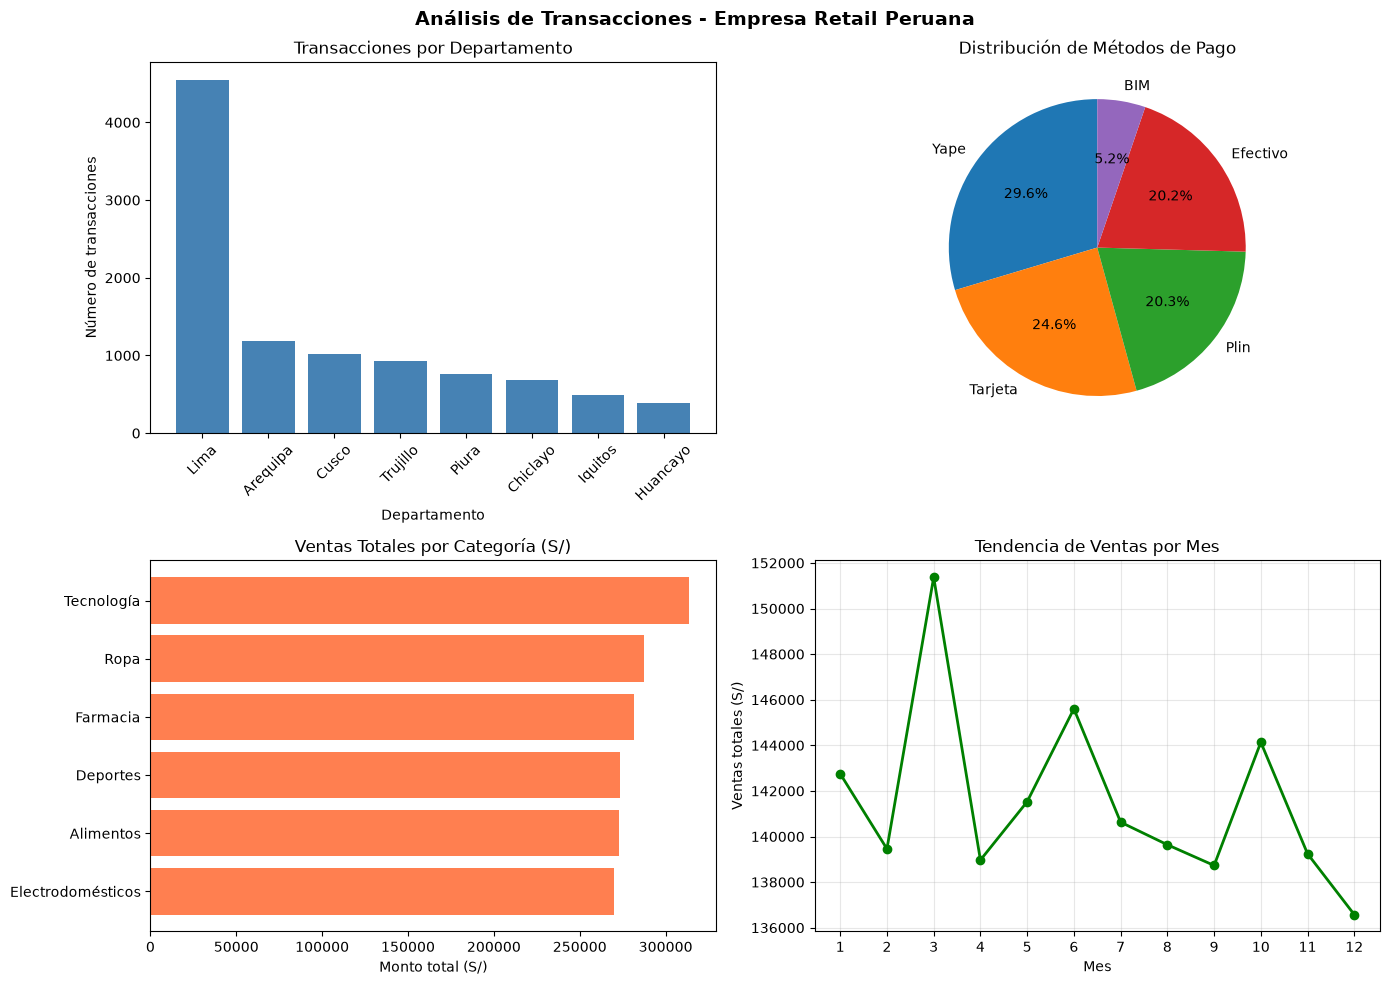

¡Gráfico guardado como 'analisis_transacciones.png'!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Análisis de Transacciones - Empresa Retail Peruana",
    fontsize=14,
    fontweight="bold",
)

trans_x_dept = transacciones["departamento"].value_counts()
axes[0, 0].bar(trans_x_dept.index, trans_x_dept.values, color="steelblue")
axes[0, 0].set_title("Transacciones por Departamento")
axes[0, 0].set_xlabel("Departamento")
axes[0, 0].set_ylabel("Número de transacciones")
axes[0, 0].tick_params(axis="x", rotation=45)

metodo_pago = transacciones["metodo_pago"].value_counts()
axes[0, 1].pie(
    metodo_pago.values,
    labels=metodo_pago.index,
    autopct="%1.1f%%",
    startangle=90,
)
axes[0, 1].set_title("Distribución de Métodos de Pago")

ventas_categoria = (
    transacciones.groupby("categoria")["monto_soles"]
    .sum()
    .sort_values(ascending=True)
)
axes[1, 0].barh(
    ventas_categoria.index,
    ventas_categoria.values,
    color="coral",
)
axes[1, 0].set_title("Ventas Totales por Categoría (S/)")
axes[1, 0].set_xlabel("Monto total (S/)")

ventas_mes = transacciones.groupby(
    transacciones["fecha"].dt.month
)["monto_soles"].sum()
axes[1, 1].plot(
    ventas_mes.index,
    ventas_mes.values,
    marker="o",
    color="green",
    linewidth=2,
)
axes[1, 1].set_title("Tendencia de Ventas por Mes")
axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Ventas totales (S/)")
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("analisis_transacciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("¡Gráfico guardado como 'analisis_transacciones.png'!")

### Interpretación de los gráficos

Lima concentra la mayor cantidad de operaciones debido a la probabilidad
asignada en la simulación. Yape y tarjeta aparecen entre los métodos más
utilizados. Como las categorías fueron elegidas con probabilidades similares,
sus ventas totales son relativamente cercanas. La tendencia mensual no
representa estacionalidad real, pues las fechas y montos fueron simulados.

## Parte 3: Datos semi-estructurados - JSON

JSON es semi-estructurado porque usa claves y jerarquías, pero admite objetos
con listas, elementos anidados y valores nulos sin exigir una tabla rígida.

In [6]:
datos_clientes_json = """
[
    {
        "id": "CLI-001",
        "nombres": "Juan Carlos",
        "apellidos": "Quispe Mamani",
        "dni": "45678901",
        "contacto": {
            "email": "jquispe@empresa.com",
            "telefono": "987654321",
            "distrito": "San Miguel"
        },
        "compras": [150.50, 320.00, 89.90],
        "fecha_registro": "2023-01-15",
        "activo": true,
        "etiquetas": ["premium", "fiel", "digital"]
    },
    {
        "id": "CLI-002",
        "nombres": "Maria Elena",
        "apellidos": "Torres Flores",
        "dni": "56789012",
        "contacto": {
            "email": "matorres@gmail.com",
            "telefono": null,
            "distrito": "Miraflores"
        },
        "compras": [500.00, 1200.50],
        "fecha_registro": "2023-03-22",
        "activo": true,
        "etiquetas": ["vip", "presencial"]
    },
    {
        "id": "CLI-003",
        "nombres": "Roberto",
        "apellidos": "Mendoza García",
        "dni": "67890123",
        "contacto": {
            "email": null,
            "telefono": "976543210",
            "distrito": "Callao"
        },
        "compras": [],
        "fecha_registro": "2024-01-05",
        "activo": false,
        "etiquetas": ["nuevo", "inactivo"]
    }
]
"""

clientes = json.loads(datos_clientes_json)
print(f"Número de clientes: {len(clientes)}")
print("\nEstructura del primer cliente:")
print(json.dumps(clientes[0], indent=2, ensure_ascii=False))

Número de clientes: 3

Estructura del primer cliente:
{
  "id": "CLI-001",
  "nombres": "Juan Carlos",
  "apellidos": "Quispe Mamani",
  "dni": "45678901",
  "contacto": {
    "email": "jquispe@empresa.com",
    "telefono": "987654321",
    "distrito": "San Miguel"
  },
  "compras": [
    150.5,
    320.0,
    89.9
  ],
  "fecha_registro": "2023-01-15",
  "activo": true,
  "etiquetas": [
    "premium",
    "fiel",
    "digital"
  ]
}


In [7]:
datos_tabulares = []
for cliente in clientes:
    datos_tabulares.append({
        "id": cliente["id"],
        "nombre_completo": (
            f"{cliente['nombres']} {cliente['apellidos']}"
        ),
        "dni": cliente["dni"],
        "distrito": cliente["contacto"]["distrito"],
        "tiene_email": cliente["contacto"]["email"] is not None,
        "tiene_telefono": cliente["contacto"]["telefono"] is not None,
        "total_compras": sum(cliente["compras"]),
        "num_compras": len(cliente["compras"]),
        "activo": cliente["activo"],
        "es_premium": (
            "premium" in cliente["etiquetas"]
            or "vip" in cliente["etiquetas"]
        ),
    })

df_clientes = pd.DataFrame(datos_tabulares)
print("=== CLIENTES CONVERTIDOS DE JSON A TABLA ===")
display(df_clientes)

print("\n=== RESUMEN DE COMPLETITUD DE DATOS ===")
print(
    f"Clientes con email: "
    f"{df_clientes['tiene_email'].sum()}/{len(df_clientes)}"
)
print(
    f"Clientes con teléfono: "
    f"{df_clientes['tiene_telefono'].sum()}/{len(df_clientes)}"
)
print(
    f"Clientes activos: "
    f"{df_clientes['activo'].sum()}/{len(df_clientes)}"
)
print(
    f"Clientes premium/VIP: "
    f"{df_clientes['es_premium'].sum()}/{len(df_clientes)}"
)

=== CLIENTES CONVERTIDOS DE JSON A TABLA ===


,id,nombre_completo,dni,distrito,tiene_email,tiene_telefono,total_compras,num_compras,activo,es_premium
0,CLI-001,Juan Carlos Quispe Mamani,45678901,San Miguel,True,True,560.4,3,True,True
1,CLI-002,Maria Elena Torres Flores,56789012,Miraflores,True,False,1700.5,2,True,True
2,CLI-003,Roberto Mendoza García,67890123,Callao,False,True,0.0,0,False,False



=== RESUMEN DE COMPLETITUD DE DATOS ===
Clientes con email: 2/3
Clientes con teléfono: 2/3
Clientes activos: 2/3
Clientes premium/VIP: 2/3


### Interpretación del JSON

Dos de los tres clientes tienen correo, dos tienen teléfono y dos están
activos. La transformación demuestra que los elementos anidados pueden
convertirse en variables tabulares. También evidencia un problema de
veracidad/completitud: no todos los clientes tienen los mismos datos de
contacto y uno todavía no registra compras.

## Parte 4: Datos no estructurados - Texto

Los comentarios están escritos en lenguaje natural y no siguen un esquema de
columnas. Se aplica un clasificador sencillo basado en palabras clave.

In [8]:
comentarios_clientes = [
    "Excelente servicio en Plaza Vea de San Miguel, muy rápido el pago con Yape!",
    "Pésima atención, esperé 30 minutos para ser atendido, nunca más voy a Tottus de La Molina",
    "El producto llegó a tiempo pero la caja estaba dañada. Regular la experiencia",
    "Super bueno el envío express de Ripley, llegó en 2 horas a Miraflores",
    "Me cobraron de más y cuando reclamé me tardaron 1 semana en devolver el dinero",
    "El área de electrónica tiene todo, encontré el celular que buscaba a buen precio",
    "App del supermercado se cae constantemente, muy mala experiencia digital",
    "Calidad del producto excelente pero precio alto comparado con Metro",
    "Personal muy amable y capacitado para asesorar sobre productos",
    "Compré en línea y el producto era diferente a la foto, decepcionante",
]

print("=== ANÁLISIS DE DATOS NO ESTRUCTURADOS (TEXTO) ===")
print(f"Total de comentarios: {len(comentarios_clientes)}")

palabras_positivas = [
    "excelente", "super", "bueno", "rápido", "amable", "calidad",
]
palabras_negativas = [
    "pésima", "mala", "dañada", "tardaron", "decepcionante", "se cae",
]

resultados = []
for i, comentario in enumerate(comentarios_clientes, 1):
    texto_lower = comentario.lower()
    score_pos = sum(
        1 for palabra in palabras_positivas if palabra in texto_lower
    )
    score_neg = sum(
        1 for palabra in palabras_negativas if palabra in texto_lower
    )

    if score_pos > score_neg:
        sentimiento = "POSITIVO"
    elif score_neg > score_pos:
        sentimiento = "NEGATIVO"
    else:
        sentimiento = "NEUTRO"

    resultados.append({
        "id": i,
        "sentimiento": sentimiento,
        "num_palabras": len(comentario.split()),
        "comentario": comentario[:50] + "...",
    })

df_sentimientos = pd.DataFrame(resultados)
print("\n=== RESULTADOS DE ANÁLISIS DE SENTIMIENTO ===")
display(df_sentimientos)

print("\n=== RESUMEN ===")
print(df_sentimientos["sentimiento"].value_counts())

=== ANÁLISIS DE DATOS NO ESTRUCTURADOS (TEXTO) ===
Total de comentarios: 10

=== RESULTADOS DE ANÁLISIS DE SENTIMIENTO ===


,id,sentimiento,num_palabras,comentario
0,1,POSITIVO,14,"Excelente servicio en Plaza Vea de San Miguel,..."
1,2,NEGATIVO,16,"Pésima atención, esperé 30 minutos para ser at..."
2,3,NEGATIVO,13,El producto llegó a tiempo pero la caja estaba...
3,4,POSITIVO,13,"Super bueno el envío express de Ripley, llegó ..."
4,5,NEGATIVO,15,Me cobraron de más y cuando reclamé me tardaro...
5,6,NEUTRO,14,"El área de electrónica tiene todo, encontré el..."
6,7,NEGATIVO,10,"App del supermercado se cae constantemente, mu..."
7,8,POSITIVO,10,Calidad del producto excelente pero precio alt...
8,9,POSITIVO,9,Personal muy amable y capacitado para asesorar...
9,10,NEGATIVO,12,Compré en línea y el producto era diferente a ...



=== RESUMEN ===
sentimiento
NEGATIVO    5
POSITIVO    4
NEUTRO      1
Name: count, dtype: int64


### Interpretación y limitaciones

El método permite una primera clasificación, pero no comprende contexto,
negaciones, ironía ni intensidad. Por ejemplo, un comentario puede contener
una palabra positiva y otra negativa. En un proyecto real se debería limpiar
el texto y utilizar un modelo de procesamiento de lenguaje natural entrenado
con comentarios en español.

## Parte 5: Diseño de arquitectura Big Data

Se propone una arquitectura para **Plaza Vea**, empresa retail peruana. El
objetivo es integrar ventas, pagos, navegación y opiniones para detectar
fraudes, personalizar ofertas y mejorar la experiencia del cliente.

### Supuestos de volumen

- 200 tiendas.
- 2 500 transacciones diarias por tienda.
- 2 KB por evento integrado, incluyendo metadatos.
- 500 000 eventos diarios.
- Aproximadamente 348 GB por año sin considerar compresión ni réplicas.

In [9]:
tiendas = 200
transacciones_por_tienda = 2500
kb_por_evento = 2

registros_por_dia = tiendas * transacciones_por_tienda
gb_por_año = (
    registros_por_dia * 365 * kb_por_evento / 1024 / 1024
)

arquitectura = {
    "empresa": "Plaza Vea - Supermercados Peruanos S.A.",
    "problema_principal": (
        "Integrar datos de tiendas físicas y canales digitales para "
        "detectar fraude, recomendar productos y analizar la experiencia "
        "del cliente con baja latencia."
    ),
    "fuentes_de_datos": {
        "estructuradas": [
            "Base de datos de ventas POS",
            "Catálogo, inventario y programa de fidelización",
            "Pagos y devoluciones",
        ],
        "semi_estructuradas": [
            "APIs de Yape, Plin y pasarelas de tarjeta",
            "Eventos JSON de la aplicación y tienda web",
            "Logs de servidores y cajas",
        ],
        "no_estructuradas": [
            "Comentarios en redes sociales",
            "Chats y correos de atención",
            "Imágenes de productos y videos de seguridad",
        ],
    },
    "estimacion_volumen": {
        "registros_por_dia": f"{registros_por_dia:,}",
        "tamaño_estimado_por_año": f"{gb_por_año:.1f} GB",
    },
    "tecnologias_propuestas": {
        "ingesta": "Apache Kafka para eventos y Airflow para cargas batch",
        "almacenamiento": "Data Lake en Amazon S3 y Data Warehouse Redshift",
        "procesamiento": "Apache Spark y Python",
        "visualizacion": "Power BI",
    },
    "casos_uso_principales": [
        "Detección de fraude en pagos y devoluciones en tiempo real",
        "Recomendación personalizada de productos y promociones",
        "Pronóstico de demanda para optimizar inventario",
        "Análisis de sentimiento de comentarios y reclamos",
    ],
}

print(json.dumps(arquitectura, indent=2, ensure_ascii=False))

{
  "empresa": "Plaza Vea - Supermercados Peruanos S.A.",
  "problema_principal": "Integrar datos de tiendas físicas y canales digitales para detectar fraude, recomendar productos y analizar la experiencia del cliente con baja latencia.",
  "fuentes_de_datos": {
    "estructuradas": [
      "Base de datos de ventas POS",
      "Catálogo, inventario y programa de fidelización",
      "Pagos y devoluciones"
    ],
    "semi_estructuradas": [
      "APIs de Yape, Plin y pasarelas de tarjeta",
      "Eventos JSON de la aplicación y tienda web",
      "Logs de servidores y cajas"
    ],
    "no_estructuradas": [
      "Comentarios en redes sociales",
      "Chats y correos de atención",
      "Imágenes de productos y videos de seguridad"
    ]
  },
  "estimacion_volumen": {
    "registros_por_dia": "500,000",
    "tamaño_estimado_por_año": "348.1 GB"
  },
  "tecnologias_propuestas": {
    "ingesta": "Apache Kafka para eventos y Airflow para cargas batch",
    "almacenamiento": "Data Lake en

### Flujo propuesto

```text
POS / pagos / aplicación / web / redes sociales
                        |
               Kafka + Airflow
                        |
              Data Lake en Amazon S3
                        |
          Apache Spark + modelos analíticos
                        |
              Amazon Redshift / APIs
                        |
            Power BI + alertas operativas
```

Kafka recibe eventos que requieren respuesta rápida, mientras Airflow
coordina las cargas programadas. El Data Lake conserva los datos originales.
Spark limpia, integra y genera variables para los modelos. Los resultados
preparados se publican en el Data Warehouse y en APIs para alertas de fraude
o recomendaciones. La plataforma debe incluir cifrado, control de acceso,
catálogo, trazabilidad y reglas de calidad.

## Conclusiones

1. Los datos estructurados son fáciles de consultar, pero aun así requieren
   controles de calidad y una arquitectura que pueda crecer.
2. JSON facilita el intercambio entre sistemas, aunque sus jerarquías deben
   transformarse para determinados análisis.
3. El texto contiene información valiosa, pero necesita técnicas de lenguaje
   natural para interpretarse con mayor precisión.
4. Una solución Big Data debe conectar la tecnología con casos de negocio y
   considerar seguridad, gobierno y calidad desde el diseño.